# Causal Reasoning — From Correlation to "Why"

Security teams routinely confuse correlation with causation. "Organizations that deployed
MFA had fewer breaches" doesn't mean MFA caused the reduction — maybe mature programs
deploy MFA AND do twenty other things that actually drive the outcome. Without causal
reasoning, we credit the wrong controls, waste budget, and draw conclusions that
fall apart under scrutiny.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from decision_security.synth import make_rng
from decision_security.causal import (
    backdoor_adjustment_set, parents, children, descendants, topological_sort
)

rng = make_rng(42)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PRIMARY = "#1A1A1A"
ACCENT = "#E74C3C"
DARK_BG = "#34495E"
LIGHT_GRAY = "#95A5A6"
MED_GRAY = "#7F8C8D"
VERY_LIGHT = "#BDC3C7"

## Simpson's Paradox in Patch Rates

Two business units report aggregate incident counts. Unit A looks worse overall.
But when we stratify by risk tier, Unit A has better patch rates — and lower
incident rates — in *both* tiers. The aggregate reversal happens because Unit A
operates mostly high-risk systems.

In [2]:
data = pd.DataFrame([
    {"unit": "A", "tier": "high-risk",  "systems": 1000, "patch_rate": 0.80, "incident_rate": 0.15},
    {"unit": "A", "tier": "low-risk",   "systems": 200,  "patch_rate": 0.90, "incident_rate": 0.02},
    {"unit": "B", "tier": "high-risk",  "systems": 200,  "patch_rate": 0.70, "incident_rate": 0.18},
    {"unit": "B", "tier": "low-risk",   "systems": 1000, "patch_rate": 0.85, "incident_rate": 0.03},
])

data["incidents"] = (data["systems"] * data["incident_rate"]).astype(int)
data["patched"]   = (data["systems"] * data["patch_rate"]).astype(int)

print("=== By risk tier (the truth) ===")
print(data[["unit", "tier", "systems", "patch_rate", "incident_rate"]].to_string(index=False))

agg = data.groupby("unit").agg(
    total_systems=("systems", "sum"),
    total_incidents=("incidents", "sum"),
    total_patched=("patched", "sum")
).reset_index()
agg["agg_patch_rate"]    = agg["total_patched"] / agg["total_systems"]
agg["agg_incident_rate"] = agg["total_incidents"] / agg["total_systems"]

print("\n=== Aggregate (the lie) ===")
print(agg[["unit", "total_systems", "agg_patch_rate", "agg_incident_rate"]].to_string(index=False))
print("\nUnit A looks worse in aggregate despite better rates in BOTH tiers.")

=== By risk tier (the truth) ===
unit      tier  systems  patch_rate  incident_rate
   A high-risk     1000        0.80           0.15
   A  low-risk      200        0.90           0.02
   B high-risk      200        0.70           0.18
   B  low-risk     1000        0.85           0.03

=== Aggregate (the lie) ===
unit  total_systems  agg_patch_rate  agg_incident_rate
   A           1200        0.816667           0.128333
   B           1200        0.825000           0.055000

Unit A looks worse in aggregate despite better rates in BOTH tiers.


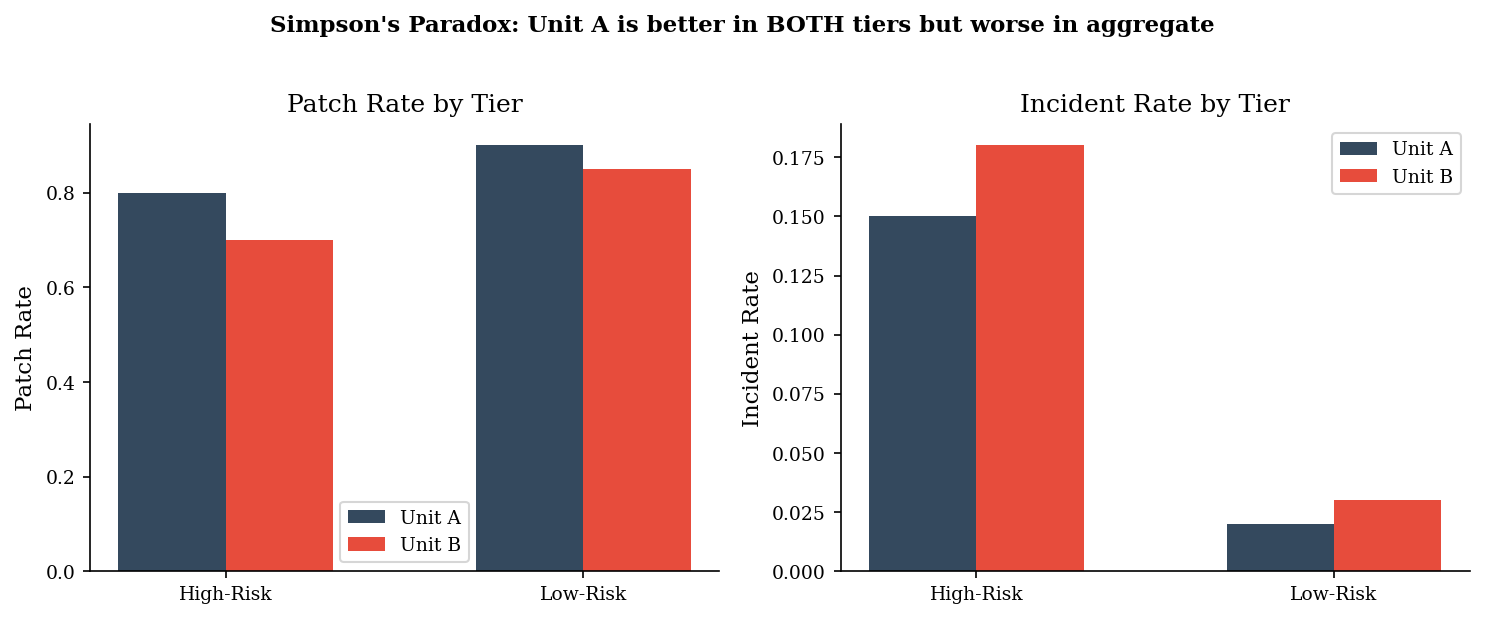

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, metric, label in zip(axes, ["patch_rate", "incident_rate"], ["Patch Rate", "Incident Rate"]):
    x = np.arange(2)
    width = 0.3
    a_vals = data[data["unit"] == "A"][metric].values
    b_vals = data[data["unit"] == "B"][metric].values
    ax.bar(x - width/2, a_vals, width, label="Unit A", color=DARK_BG)
    ax.bar(x + width/2, b_vals, width, label="Unit B", color=ACCENT)
    ax.set_xticks(x)
    ax.set_xticklabels(["High-Risk", "Low-Risk"])
    ax.set_ylabel(label)
    ax.set_title(f"{label} by Tier")
    ax.legend()

fig.suptitle("Simpson's Paradox: Unit A is better in BOTH tiers but worse in aggregate",
             fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## DAGs: Drawing the Causal Structure

A directed acyclic graph (DAG) encodes assumptions about what causes what.
Drawing the arrows *is* the modeling decision — the math just follows.
Here's a simple security DAG: budget drives training, patching, and MFA;
patching and MFA both affect incidents.

In [4]:
nodes = ["budget", "training", "patching", "mfa", "incidents"]
edges = [
    ("budget", "training"),
    ("budget", "patching"),
    ("budget", "mfa"),
    ("training", "patching"),
    ("patching", "incidents"),
    ("mfa", "incidents"),
]

order = topological_sort(nodes, edges)
print(f"Topological order: {order}")
print(f"Parents of patching:    {parents(edges, 'patching')}")
print(f"Children of budget:     {children(edges, 'budget')}")
print(f"Descendants of budget:  {descendants(edges, 'budget')}")

Topological order: ['budget', 'mfa', 'training', 'patching', 'incidents']
Parents of patching:    {'training', 'budget'}
Children of budget:     {'mfa', 'training', 'patching'}
Descendants of budget:  {'mfa', 'training', 'incidents', 'patching'}


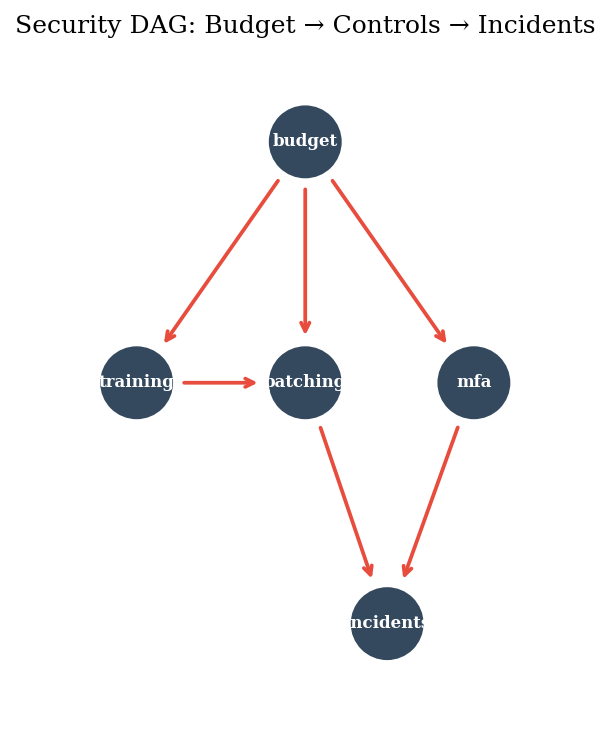

In [5]:
pos = {
    "budget":    (0.5, 1.0),
    "training":  (0.15, 0.5),
    "patching":  (0.5, 0.5),
    "mfa":       (0.85, 0.5),
    "incidents": (0.67, 0.0),
}

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.2, 1.2)
ax.set_aspect("equal")
ax.axis("off")

for node, (x, y) in pos.items():
    circle = plt.Circle((x, y), 0.08, fc=DARK_BG, ec="white", linewidth=2, zorder=3)
    ax.add_patch(circle)
    ax.text(x, y, node, ha="center", va="center", fontsize=8,
            fontweight="bold", color="white", zorder=4)

for u, v in edges:
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    dx, dy = x1 - x0, y1 - y0
    dist = np.sqrt(dx**2 + dy**2)
    shrink = 0.09 / dist
    ax.annotate("",
        xy=(x1 - dx * shrink, y1 - dy * shrink),
        xytext=(x0 + dx * shrink, y0 + dy * shrink),
        arrowprops=dict(arrowstyle="->", color=ACCENT, lw=1.8))

ax.set_title("Security DAG: Budget → Controls → Incidents", fontsize=12)
plt.tight_layout()
plt.show()

## Confounders, Mediators, Colliders

Three path types determine whether a statistical association reflects a causal
relationship. Getting these wrong is how security teams draw the wrong conclusions
from observational data.

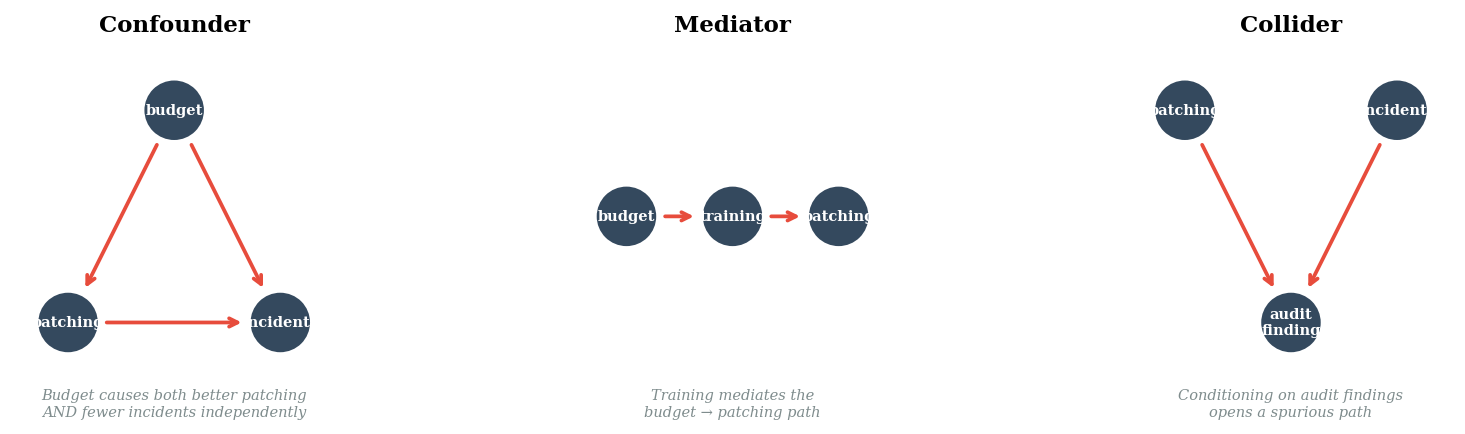

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

configs = [
    ("Confounder", {"budget": (0.5, 0.9), "patching": (0.1, 0.1), "incidents": (0.9, 0.1)},
     [("budget", "patching"), ("budget", "incidents"), ("patching", "incidents")],
     "Budget causes both better patching\nAND fewer incidents independently"),
    ("Mediator", {"budget": (0.1, 0.5), "training": (0.5, 0.5), "patching": (0.9, 0.5)},
     [("budget", "training"), ("training", "patching")],
     "Training mediates the\nbudget → patching path"),
    ("Collider", {"patching": (0.1, 0.9), "incidents": (0.9, 0.9), "audit": (0.5, 0.1)},
     [("patching", "audit"), ("incidents", "audit")],
     "Conditioning on audit findings\nopens a spurious path"),
]

for ax, (title, positions, arrows, note) in zip(axes, configs):
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.2, 1.15)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=11, fontweight="bold")

    for node, (x, y) in positions.items():
        label = "audit\nfinding" if node == "audit" else node
        circle = plt.Circle((x, y), 0.12, fc=DARK_BG, ec="white", lw=2, zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, label, ha="center", va="center", fontsize=7,
                fontweight="bold", color="white", zorder=4)

    for u, v in arrows:
        x0, y0 = positions[u]
        x1, y1 = positions[v]
        dx, dy = x1 - x0, y1 - y0
        dist = np.sqrt(dx**2 + dy**2)
        shrink = 0.13 / dist
        ax.annotate("",
            xy=(x1 - dx * shrink, y1 - dy * shrink),
            xytext=(x0 + dx * shrink, y0 + dy * shrink),
            arrowprops=dict(arrowstyle="->", color=ACCENT, lw=1.8))

    ax.text(0.5, -0.15, note, ha="center", va="top", fontsize=7,
            style="italic", color=MED_GRAY)

plt.tight_layout()
plt.show()

## The Backdoor Criterion

To estimate the causal effect of patching on incidents, we need to block all
"backdoor paths" — non-causal paths that flow through common causes. The
library's `backdoor_adjustment_set` identifies which variables to condition on.

In [7]:
candidates = {"budget", "training", "mfa"}
adj_set = backdoor_adjustment_set(edges, "patching", "incidents", candidates)
print(f"Adjustment set for patching → incidents: {adj_set}")
print(f"Control for these variables to isolate the causal effect of patching.")

Adjustment set for patching → incidents: {'training', 'budget'}
Control for these variables to isolate the causal effect of patching.


## Naive vs Adjusted: Why the Backdoor Matters

We generate synthetic data where budget confounds patching and incidents.
The naive correlation overstates the effect of patching because it picks up
the budget confound. Stratifying by budget isolates the true causal effect.

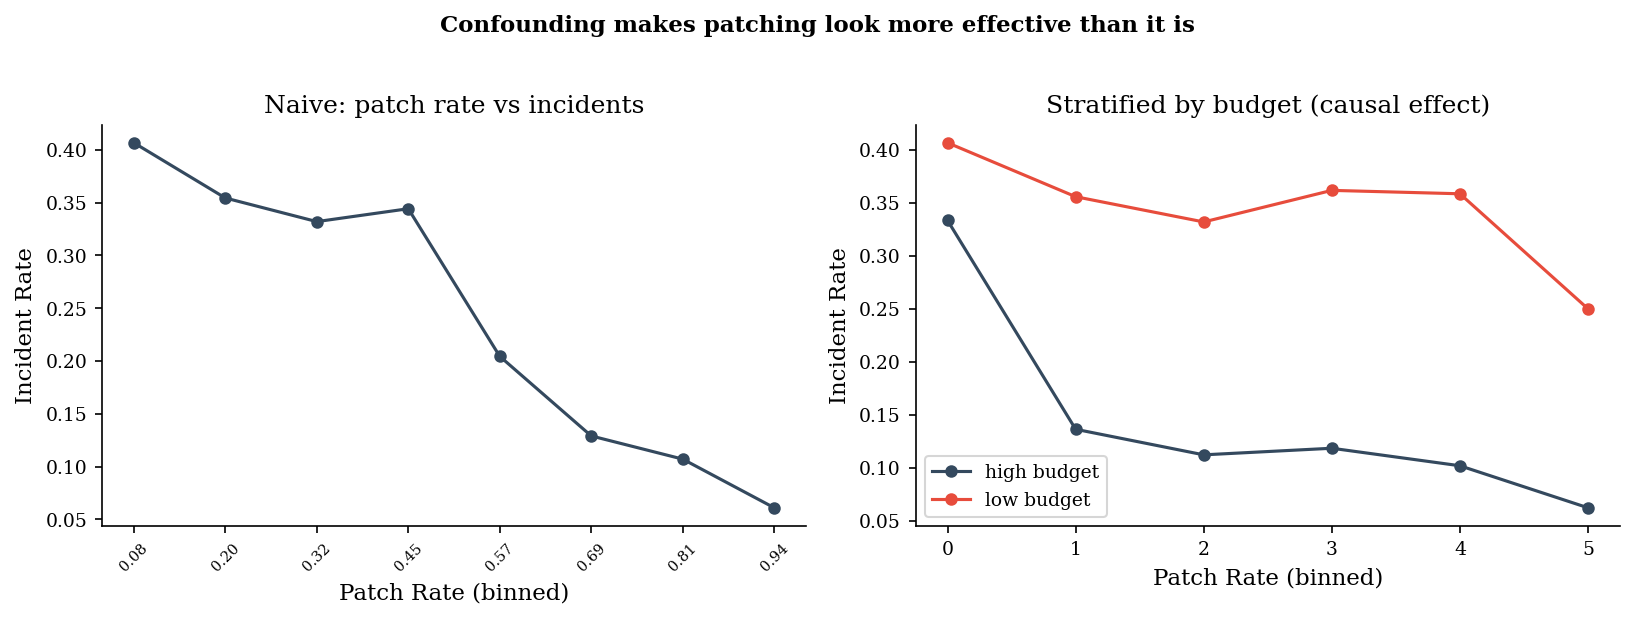

In [8]:
n = 2000
budget = rng.choice(["low", "high"], n, p=[0.4, 0.6])
is_high = budget == "high"

patch_rate = np.where(is_high,
    rng.beta(8, 2, n),
    rng.beta(3, 7, n)
)

base_incident = np.where(is_high, 0.08, 0.25)
p_incident = np.clip(base_incident + 0.12 * (1 - patch_rate), 0, 1)
incident = rng.binomial(1, p_incident)

df = pd.DataFrame({"budget": budget, "patch_rate": patch_rate, "incident": incident})

bins = pd.cut(df["patch_rate"], bins=8)
naive = df.groupby(bins, observed=True)["incident"].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(range(len(naive)), naive.values, "o-", color=DARK_BG, markersize=5)
axes[0].set_xticks(range(len(naive)))
axes[0].set_xticklabels([f"{iv.mid:.2f}" for iv in naive.index], rotation=45, fontsize=7)
axes[0].set_xlabel("Patch Rate (binned)")
axes[0].set_ylabel("Incident Rate")
axes[0].set_title("Naive: patch rate vs incidents")

for label, color in [("high", DARK_BG), ("low", ACCENT)]:
    sub = df[df["budget"] == label]
    bins_s = pd.cut(sub["patch_rate"], bins=6)
    strat = sub.groupby(bins_s, observed=True)["incident"].mean()
    axes[1].plot(range(len(strat)), strat.values, "o-", color=color,
                markersize=5, label=f"{label} budget")

axes[1].set_xlabel("Patch Rate (binned)")
axes[1].set_ylabel("Incident Rate")
axes[1].set_title("Stratified by budget (causal effect)")
axes[1].legend()

fig.suptitle("Confounding makes patching look more effective than it is",
             fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Observing vs Intervening

The core insight of causal inference: *P(incidents | observe patch=high)* differs from
*P(incidents | do(patch=high))*. Observing high patch rates includes the confound —
high-budget orgs self-select into high patching. Intervening (forcing patch rates
high for everyone) breaks the incoming arrows to patching and isolates the direct effect.

In [9]:
high_patchers = df[df["patch_rate"] > 0.7]
p_obs = high_patchers["incident"].mean()

p_do_high = 0
p_do_low = 0
for b_level in ["low", "high"]:
    sub = df[df["budget"] == b_level]
    high_p = sub[sub["patch_rate"] > 0.7]
    weight = len(sub) / len(df)
    if len(high_p) > 0:
        p_do_high += high_p["incident"].mean() * weight

low_patchers = df[df["patch_rate"] <= 0.3]
p_obs_low = low_patchers["incident"].mean()

for b_level in ["low", "high"]:
    sub = df[df["budget"] == b_level]
    low_p = sub[sub["patch_rate"] <= 0.3]
    weight = len(sub) / len(df)
    if len(low_p) > 0:
        p_do_low += low_p["incident"].mean() * weight

print("=== Observe vs Intervene ===")
print(f"P(incident | observe patch > 0.7) = {p_obs:.3f}")
print(f"P(incident | do(patch > 0.7))     = {p_do_high:.3f}  (adjusted for budget)")
print(f"")
print(f"P(incident | observe patch ≤ 0.3) = {p_obs_low:.3f}")
print(f"P(incident | do(patch ≤ 0.3))     = {p_do_low:.3f}  (adjusted for budget)")
print(f"")
print(f"Naive effect:    {p_obs_low - p_obs:.3f} (confounded — overstated)")
print(f"Causal effect:   {p_do_low - p_do_high:.3f} (adjusted — the real signal)")

=== Observe vs Intervene ===
P(incident | observe patch > 0.7) = 0.096
P(incident | do(patch > 0.7))     = 0.254  (adjusted for budget)

P(incident | observe patch ≤ 0.3) = 0.362
P(incident | do(patch ≤ 0.3))     = 0.143  (adjusted for budget)

Naive effect:    0.265 (confounded — overstated)
Causal effect:   -0.111 (adjusted — the real signal)


## Pitfalls

- **Correlation between control deployment and fewer incidents almost always has confounders.** Maturity, budget, and culture drive both control adoption and outcomes. "We deployed X and incidents dropped" is not evidence that X caused the drop.

- **Conditioning on a collider creates phantom associations.** "Among organizations that passed their audit" is a collider condition — it makes unrelated variables appear correlated because both contribute to passing.

- **You need the counterfactual.** The question isn't "did incidents drop after we deployed MFA?" It's "what *would have happened* without MFA?" Without that comparison, post-hoc reasoning dominates.

- **DAGs encode assumptions, not facts.** Drawing the arrows IS the modeling decision. Two analysts can draw different DAGs for the same situation and reach opposite conclusions. The diagram should be debated, not the regression output.